In [1]:
import numpy as np 
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
import re
import nltk
import string
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)


import os
print(os.getcwd())
data=pd.read_csv(r"C:\Users\aadhi\Downloads\dataset.csv (5).zip")

data=data.iloc[:,1:]

c:\Users\aadhi\OneDrive\Desktop\projects


In [2]:
data=data.sample(frac=1)



In [3]:
data=data.sample(frac=1)


In [4]:
data.head()

,filename,reviews,label
7619,5608_9.txt,"Sure, he became rapidly uneven after this film...",1
9945,7701_10.txt,This has always been one of my favourite movie...,1
19926,5434_1.txt,Wow. What a terrible adaptation of a beautiful...,0
968,10872_7.txt,Election marks the 2nd trial society theme mov...,1
8077,601_7.txt,I was surprised at the low rating this film go...,1


In [5]:
train=data

In [6]:
train['clean_reviews']=train['reviews'].str.replace("[^a-zA-Z#]"," ")

In [7]:
train['clean_reviews'].head()

7619     Sure, he became rapidly uneven after this film...
9945     This has always been one of my favourite movie...
19926    Wow. What a terrible adaptation of a beautiful...
968      Election marks the 2nd trial society theme mov...
8077     I was surprised at the low rating this film go...
Name: clean_reviews, dtype: object

In [8]:
train['clean_reviews']=train['clean_reviews'].apply(lambda x: ' '.join([w for w in x.split() if len(w)>3]))

In [9]:
train['clean_reviews'].head()

7619     Sure, became rapidly uneven after this film, f...
9945     This always been favourite movies, will always...
19926    Wow. What terrible adaptation beautiful novel....
968      Election marks trial society theme movie direc...
8077     surprised rating this film from viewers. late ...
Name: clean_reviews, dtype: object

In [10]:
train['clean_reviews']=train['clean_reviews'].apply(lambda x: x.split())

In [11]:
train['clean_reviews'].head()

7619     [Sure,, became, rapidly, uneven, after, this, ...
9945     [This, always, been, favourite, movies,, will,...
19926    [Wow., What, terrible, adaptation, beautiful, ...
968      [Election, marks, trial, society, theme, movie...
8077     [surprised, rating, this, film, from, viewers....
Name: clean_reviews, dtype: object

In [12]:
from nltk.stem.porter import *
stemmer=PorterStemmer()
train['clean_reviews']=train['clean_reviews'].apply(lambda x: [stemmer.stem(i) for i in x])

In [13]:
train['clean_reviews'].head()

7619     [sure,, becam, rapidli, uneven, after, thi, fi...
9945     [thi, alway, been, favourit, movies,, will, al...
19926    [wow., what, terribl, adapt, beauti, novel., h...
968      [elect, mark, trial, societi, theme, movi, dir...
8077     [surpris, rate, thi, film, from, viewers., lat...
Name: clean_reviews, dtype: object

In [14]:
train['clean_reviews']=train['clean_reviews'].apply(lambda x:' '.join([w for w in x]))

In [15]:
train['clean_reviews'].head(10)

7619     sure, becam rapidli uneven after thi film, fro...
9945     thi alway been favourit movies, will alway ove...
19926    wow. what terribl adapt beauti novel. here jus...
968      elect mark trial societi theme movi direct joh...
8077     surpris rate thi film from viewers. late night...
9438     thi onli full length featur film about world b...
8264     would'v imagin hartley creat filmic corollari ...
566      thi amaz documentari give glimps into live bra...
8339     get ahead myself here, although film itself te...
1196     first all, don't into revolv expect anoth snat...
Name: clean_reviews, dtype: object

In [16]:
from wordcloud import WordCloud

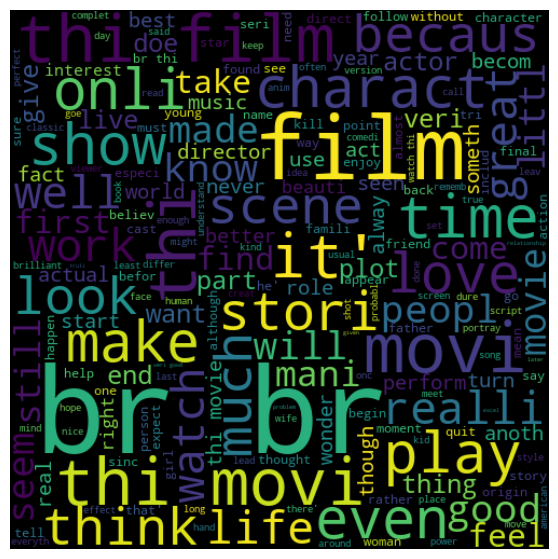

In [17]:
good_words=' '.join([text for text in train['clean_reviews'][train['label']==1]])
wc=WordCloud(height=500, width=500, random_state=21, max_font_size=110).generate(good_words)
plt.figure(figsize=(7,7))
plt.imshow(wc, interpolation="bilinear")
plt.axis('off')
plt.show()

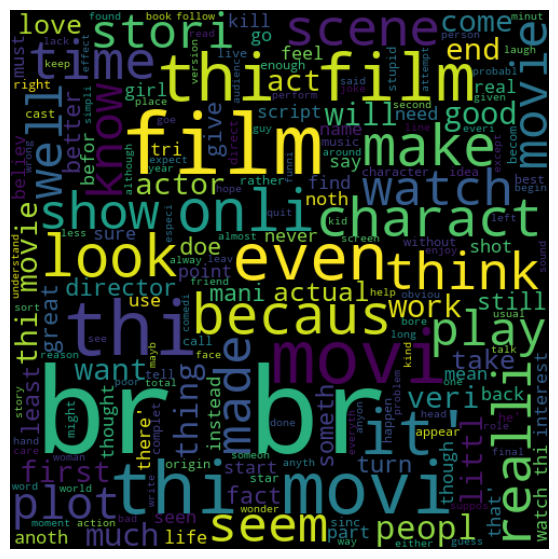

In [18]:
bad_words=' '.join([text for text in train['clean_reviews'][train['label']==0]])
wc=WordCloud(height=500, width=500, random_state=21, max_font_size=110).generate(bad_words)
plt.figure(figsize=(7,7))
plt.imshow(wc, interpolation="bilinear")
plt.axis('off')
plt.show()

In [19]:
from sklearn.feature_extraction.text import HashingVectorizer
hv=HashingVectorizer(n_features=2**10)
hvr=hv.fit_transform(train['clean_reviews'])
fea_hvr=pd.DataFrame(hvr.toarray())

In [20]:
data_hvr=pd.concat([pd.DataFrame(fea_hvr),train['label']], axis=1)

In [21]:
from sklearn.feature_extraction.text import CountVectorizer
cv=CountVectorizer(min_df=2, max_df=0.90, max_features=1000,stop_words='english')

bow=cv.fit_transform(train['clean_reviews'])


In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer
corpus = ['This is the first document.','This document is the second document.',
     'And this is the third one.',
     'Is this the first document?']
vec=TfidfVectorizer()
X=vec.fit_transform(corpus)
print("vec.get_feature_names()")
print(X.shape)
print(X)

vec.get_feature_names()
(4, 9)
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 21 stored elements and shape (4, 9)>
  Coords	Values
  (0, 8)	0.38408524091481483
  (0, 3)	0.38408524091481483
  (0, 6)	0.38408524091481483
  (0, 2)	0.5802858236844359
  (0, 1)	0.46979138557992045
  (1, 8)	0.281088674033753
  (1, 3)	0.281088674033753
  (1, 6)	0.281088674033753
  (1, 1)	0.6876235979836938
  (1, 5)	0.5386476208856763
  (2, 8)	0.267103787642168
  (2, 3)	0.267103787642168
  (2, 6)	0.267103787642168
  (2, 0)	0.511848512707169
  (2, 7)	0.511848512707169
  (2, 4)	0.511848512707169
  (3, 8)	0.38408524091481483
  (3, 3)	0.38408524091481483
  (3, 6)	0.38408524091481483
  (3, 2)	0.5802858236844359
  (3, 1)	0.46979138557992045


In [23]:
tv=TfidfVectorizer(min_df=2, max_df=0.90,  max_features=1000, stop_words='english')
tfidf=tv.fit_transform(train['clean_reviews'])
vocab="tv.get_feature_names()"
print(len(vocab))


22


In [24]:
fea_bow=pd.DataFrame(bow.toarray())
fea_tf=pd.DataFrame(tfidf.toarray())

In [25]:
from sklearn.decomposition import PCA, TruncatedSVD

x_tsvd_bow=TruncatedSVD(n_components=100,algorithm='randomized',random_state=42).fit_transform(fea_bow.values)
x_tsvd_tf=TruncatedSVD(n_components=100,algorithm='randomized',random_state=42).fit_transform(fea_tf.values)

In [26]:
data_bow=pd.concat([pd.DataFrame(x_tsvd_bow),train['label']], axis=1)
data_tf=pd.concat([pd.DataFrame(x_tsvd_tf),train['label']],axis=1)
data_bow.shape


(25000, 101)

In [27]:
corr_bow=data_bow.corr()
corr_tf=data_tf.corr()

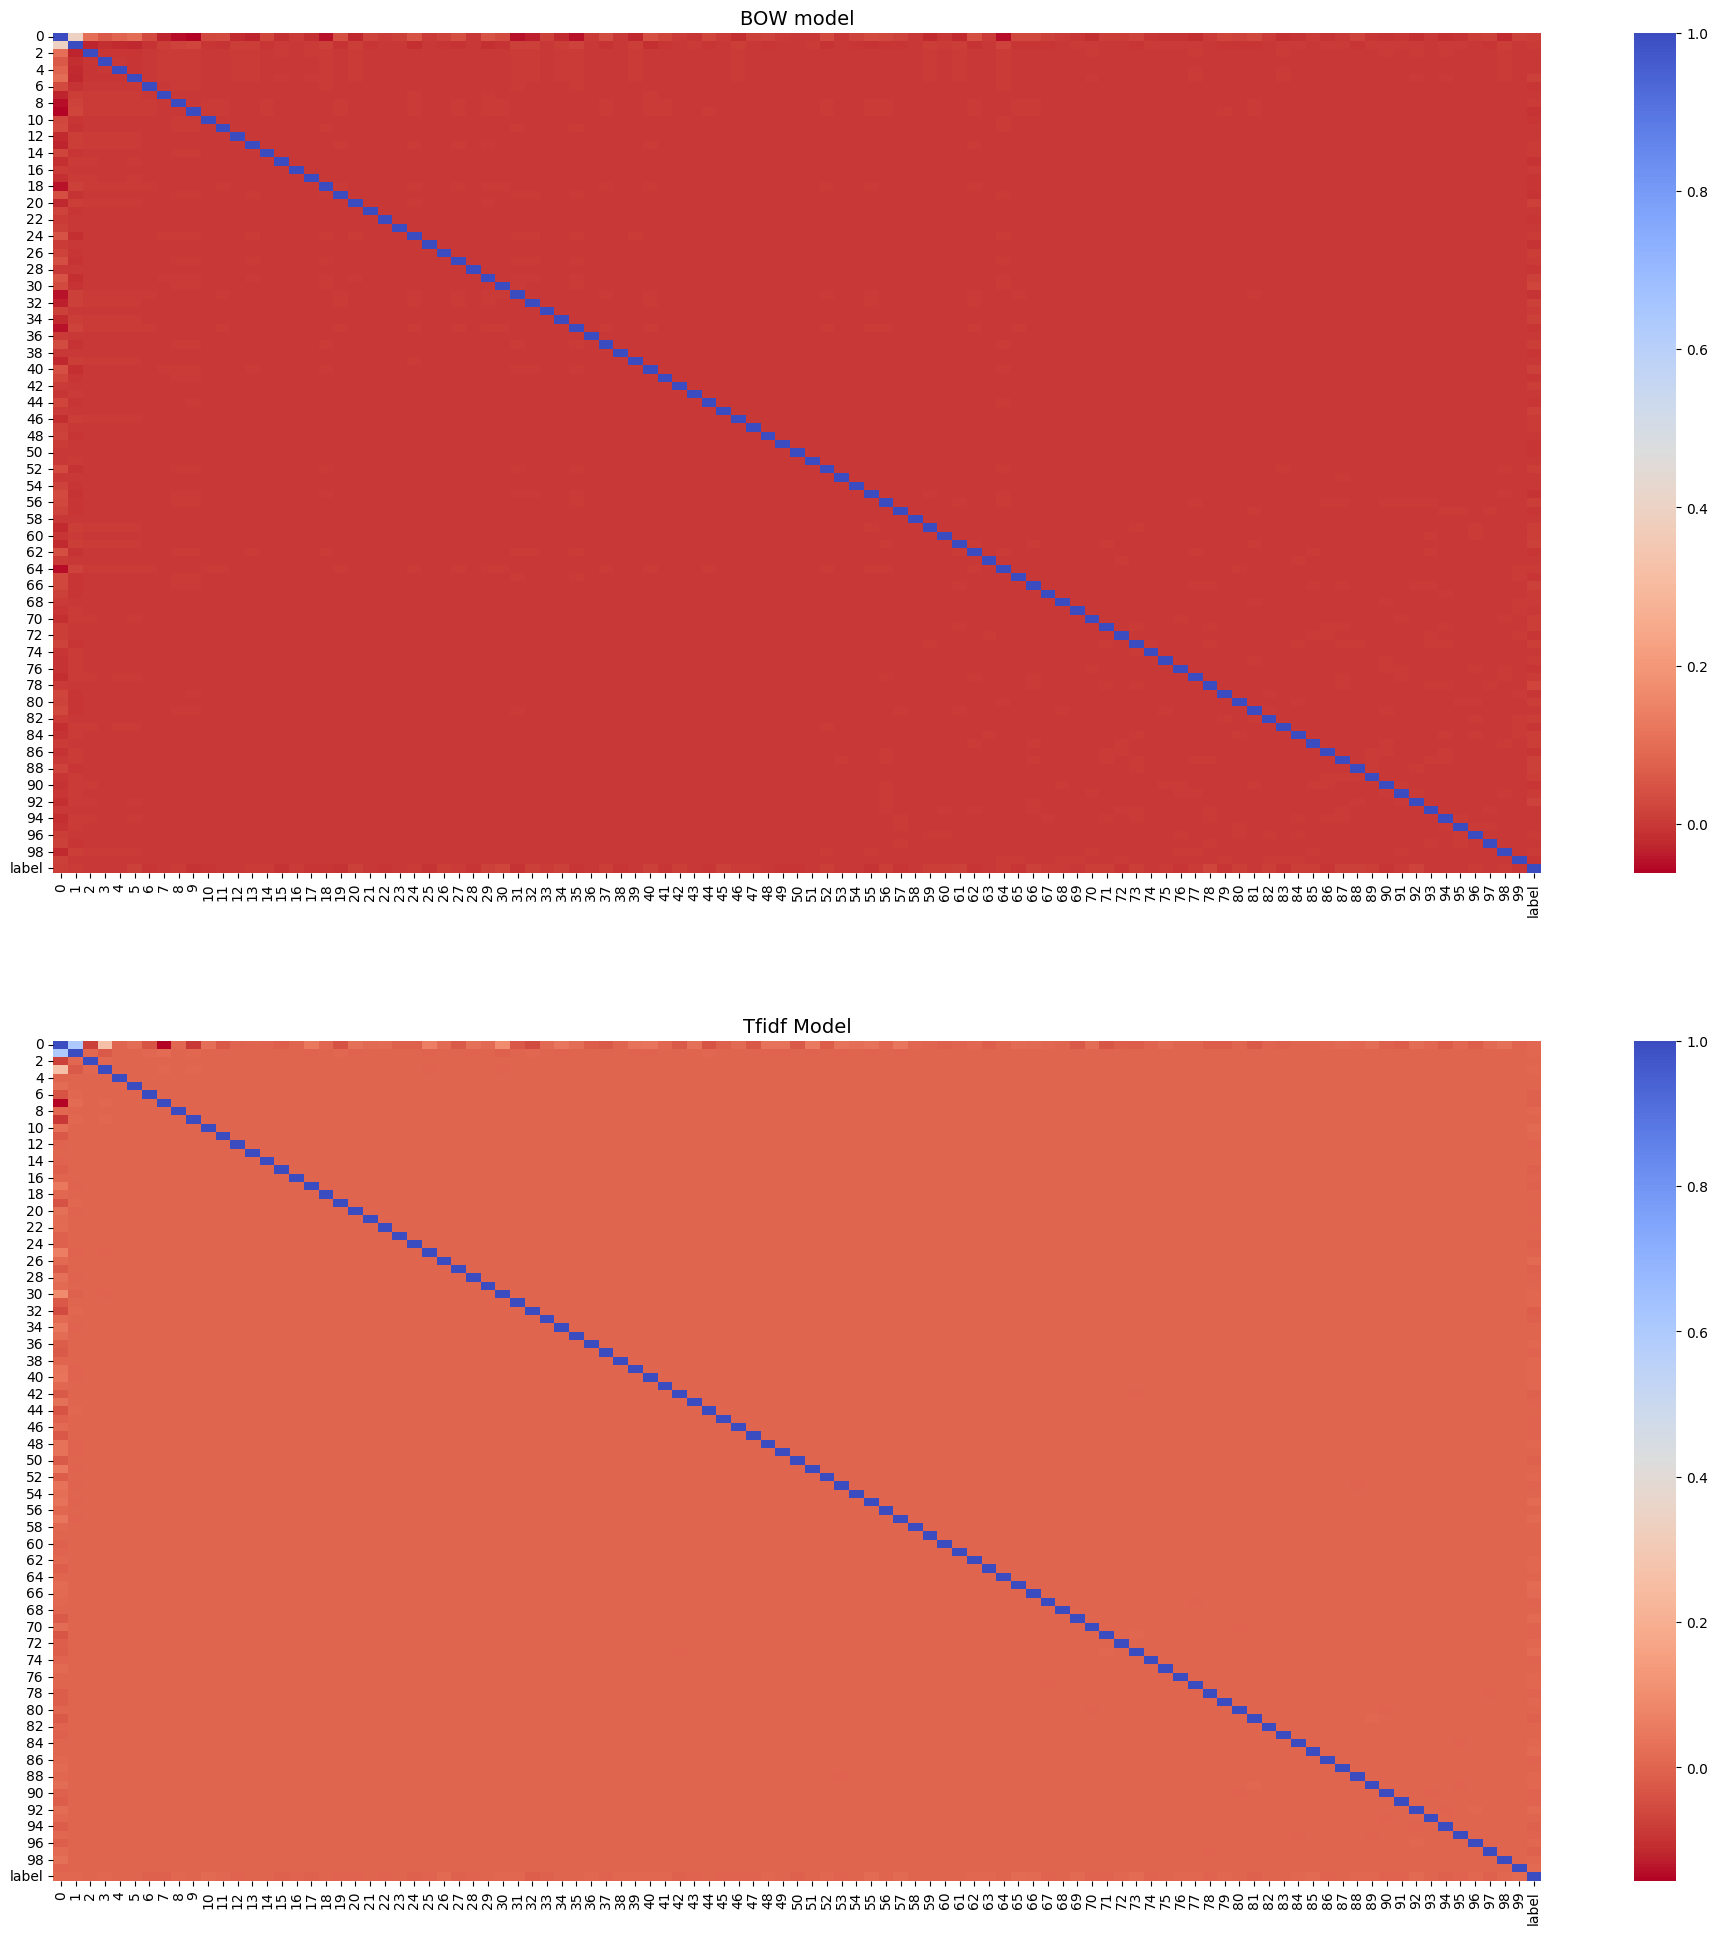

In [28]:
f, (ax1, ax2) = plt.subplots(2, 1, figsize=(24,24))
sns.heatmap(corr_bow, cmap='coolwarm_r', annot_kws={'size':20}, ax=ax1)
ax1.set_title("BOW model", fontsize=14)

sns.heatmap(corr_tf, cmap='coolwarm_r', annot_kws={'size':23})
ax2.set_title('Tfidf Model', fontsize=14)
plt.show()

In [29]:
pos_corr=corr_bow.index[corr_bow['label'] >0.010].tolist()#these eatures have strong +ve correlation
neg_corr=corr_tf.index[corr_tf['label'] <-0.011].tolist()#these eatures have strong -ve correlation
print(pos_corr,neg_corr)

[30, 34, 45, 61, 66, 78, 87, 88, 92, 'label'] [32]


In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

In [31]:
tr_bow=bow

x_tr_bow, x_val_bow, y_tr_bow, y_val_bow=train_test_split(tr_bow, train['label'],random_state=42,test_size=0.3)
model_bow=LogisticRegression()
y_tr_bow=pd.DataFrame(y_tr_bow)
model_bow.fit(x_tr_bow,y_tr_bow)
ans=model_bow.predict(x_val_bow)
f1_bow=f1_score(ans, y_val_bow)
print(f1_bow)

c:\Users\aadhi\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


0.8480556270924543


c:\Users\aadhi\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [32]:
train_tfidf = tfidf

x_tr_tf,x_val_tf,y_tr_tf,y_val_tf=train_test_split(train_tfidf,train['label'], test_size=0.3)
model_tf=LogisticRegression()
model_tf.fit(x_tr_tf,y_tr_tf)
y_pre_tf=model_tf.predict(x_val_tf)
f1_tf=f1_score(y_pre_tf,y_val_tf)
f1_tf

0.8532803180914513

In [33]:
x_tr_tf_tsvd,x_val_tf_tsvd,y_tr_tf_tsvd,y_val_tf_tsvd=train_test_split(x_tsvd_tf,train['label'], test_size=0.3)
model_tsvd_tf=LogisticRegression()
model_tsvd_tf.fit(x_tr_tf_tsvd,y_tr_tf_tsvd)
y_pre_tf_tsvd=model_tsvd_tf.predict(x_val_tf_tsvd)
f1_tf_tsvd=f1_score(y_pre_tf_tsvd,y_val_tf_tsvd)
f1_tf_tsvd

0.8310293920279157

In [34]:
train_tfidf = tfidf

x_tr_tf,x_val_tf,y_tr_tf,y_val_tf=train_test_split(train_tfidf,train['label'], test_size=0.3)
from sklearn.naive_bayes import MultinomialNB
clf=MultinomialNB()
clf.fit(x_tr_tf,y_tr_tf)
y_pre_tf=clf.predict(x_val_tf)
f1_tf=f1_score(y_pre_tf,y_val_tf)
f1_tf

0.825351379489849

In [35]:
x_tr_hvr, x_val_hvr, y_tr_hvr, y_val_hvr = train_test_split(data_hvr.drop('label', axis=1), train['label'], test_size=0.3)
model_hvr = LogisticRegression()
model_hvr.fit(x_tr_hvr, y_tr_hvr)
y_pr_hvr = model_hvr.predict(x_val_hvr)
f1_hvr = f1_score(y_val_hvr, y_pr_hvr)
f1_hvr

0.8078315676545528